# Gene Usage Batch-Correction Benchmark on AIRR COVID-19 (HF)

This notebook benchmarks batch correction on real data from `datasets/isalgo/airr_covid19`.

Pipeline:
1. Download/cache dataset in `notebooks/assets/large`.
2. Load metadata and repertoires with `RepertoireDataset.from_folder_polars(...)`.
3. Compute VJ usage correction (`compute_batch_corrected_gene_usage`).
4. Reproduce segment-usage style analyses: PCA, batch separability metrics, clustermaps, highlighted genes.
5. Re-run after `resample_to_gene_usage` and `filter_functional`.
6. Report final sample/batch/locus stats.

In [1]:
# If needed, uncomment and run once:
# %pip install -q huggingface_hub datasets polars seaborn scikit-learn umap-learn

from __future__ import annotations

from pathlib import Path
import sys
import time
import tracemalloc
from collections import Counter

# Ensure local repository sources are imported (not a stale site-packages install).
repo_root = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score

try:
    from umap import UMAP as UMAPReducer
    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False
    print('umap-learn not installed — UMAP plots will be skipped. Run: pip install umap-learn')

from huggingface_hub import snapshot_download

from mir.common.parser import VDJtoolsParser
from mir.common.repertoire_dataset import RepertoireDataset
from mir.common.sampling import resample_to_gene_usage
from mir.common.filter import filter_functional
from mir.basic.gene_usage import compute_batch_corrected_gene_usage

try:
    import psutil
except Exception:
    psutil = None

sns.set_theme(style='whitegrid', context='notebook')

/Users/mikesh/vcs/mirpy/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
asset_root = repo_root / 'notebooks' / 'assets' / 'large'
asset_root.mkdir(parents=True, exist_ok=True)

hf_local_dir = asset_root / 'airr_covid19'

hf_t0 = time.perf_counter()
if not hf_local_dir.exists() or not any(hf_local_dir.iterdir()):
    print('Downloading dataset from Hugging Face...')
    snapshot_download(
        repo_id='isalgo/airr_covid19',
        repo_type='dataset',
        local_dir=str(hf_local_dir),
        local_dir_use_symlinks=False,
    )
else:
    print(f'Using cached dataset at: {hf_local_dir}')
hf_t1 = time.perf_counter()

hf_elapsed_s = hf_t1 - hf_t0
print(f'HF dataset ready in {hf_elapsed_s:.2f} seconds')

hf_local_dir

Using cached dataset at: /Users/mikesh/vcs/mirpy/notebooks/assets/large/airr_covid19
HF dataset ready in 0.00 seconds


PosixPath('/Users/mikesh/vcs/mirpy/notebooks/assets/large/airr_covid19')

In [3]:
# Locate metadata file (robust to internal folder layout)
meta_candidates = sorted(hf_local_dir.rglob('metadata.tsv')) + sorted(hf_local_dir.rglob('*metadata*.tsv'))
if not meta_candidates:
    raise FileNotFoundError('Could not locate metadata TSV in the downloaded dataset directory.')

metadata_path = meta_candidates[0]
data_root = metadata_path.parent
print('metadata_path =', metadata_path)
print('data_root =', data_root)

meta_pl = pl.read_csv(metadata_path, separator='	', infer_schema_length=20_000)
print('metadata columns:', meta_pl.columns)

required_cols = {'sample_id', 'batch_id', 'file_name', 'locus'}
missing_cols = required_cols.difference(set(meta_pl.columns))
if missing_cols:
    raise ValueError(f'Metadata is missing required columns: {sorted(missing_cols)}')

meta_pl.head()

metadata_path = /Users/mikesh/vcs/mirpy/notebooks/assets/large/airr_covid19/metadata.tsv
data_root = /Users/mikesh/vcs/mirpy/notebooks/assets/large/airr_covid19
metadata columns: ['file_name', 'reads', 'clonotypes', 'singletons', 'doubletons', 'file_id', 'sequencing_date', 'batch_id', 'R1', 'R2', 'sample_id', 'COVID_status', 'project_name', 'COVID_IgG', 'COVID_IgM', 'COVID_PCR', 'HLA-A_1', 'HLA-A_2', 'HLA-B_1', 'HLA-B_2', 'HLA-C_1', 'HLA-C_2', 'HLA-DPB1_1', 'HLA-DPB1_2', 'HLA-DQB1_1', 'HLA-DQB1_2', 'HLA-DRB1_1', 'HLA-DRB1_2', 'donor_id', 'subsequent_sequencing', 'HLA-DRB4_1', 'HLA-DRB3_1', 'HLA-DRB5_1', 'locus', 'is_bad_reseq']


file_name,reads,clonotypes,singletons,doubletons,file_id,sequencing_date,batch_id,R1,R2,sample_id,COVID_status,project_name,COVID_IgG,COVID_IgM,COVID_PCR,HLA-A_1,HLA-A_2,HLA-B_1,HLA-B_2,HLA-C_1,HLA-C_2,HLA-DPB1_1,HLA-DPB1_2,HLA-DQB1_1,HLA-DQB1_2,HLA-DRB1_1,HLA-DRB1_2,donor_id,subsequent_sequencing,HLA-DRB4_1,HLA-DRB3_1,HLA-DRB5_1,locus,is_bad_reseq
str,i64,i64,i64,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
"""020000010808_S3_L001.TRA.vdjto…",1114519,8162,1072,528,"""020000010808_S3_L001""","""2020 10 19""","""2020/10_FMBA_NovaSeq5""","""020000010808_S3_L001_R1_001.fa…","""020000010808_S3_L001_R2_001.fa…","""020000010808""","""COVID""","""FMBA_DNA""","""yes""","""no""","""negative""","""A*02:05""","""A*24:02""","""B*35:02""","""B*50:01""","""C*04:01""","""C*06:02""","""DPB1*02:01""","""DPB1*04:02""","""DQB1*03:01""","""DQB1*05:02""","""DRB1*11:04""","""DRB1*16:01""","""020000010""",null,null,null,null,"""TRA""",null
"""020000010808_S3_L001.TRB.vdjto…",623811,4324,491,263,"""020000010808_S3_L001""","""2020 10 19""","""2020/10_FMBA_NovaSeq5""","""020000010808_S3_L001_R1_001.fa…","""020000010808_S3_L001_R2_001.fa…","""020000010808""","""COVID""","""FMBA_DNA""","""yes""","""no""","""negative""","""A*02:05""","""A*24:02""","""B*35:02""","""B*50:01""","""C*04:01""","""C*06:02""","""DPB1*02:01""","""DPB1*04:02""","""DQB1*03:01""","""DQB1*05:02""","""DRB1*11:04""","""DRB1*16:01""","""020000010""",null,null,null,null,"""TRB""",null
"""020000110808_S14_L001.TRA.vdjt…",14936089,23583,1240,505,"""020000110808_S14_L001""","""2020 09 05""","""2020/09_FMBA_NovaSeq_DNA""","""020000110808_S14_L001_R1_001.f…","""020000110808_S14_L001_R2_001.f…","""020000110808""","""COVID""","""FMBA_DNA""","""yes""","""yes""","""negative""","""A*03:01""","""A*11:01""","""B*18:01""","""B*35:01""","""C*04:01""","""C*12:03""","""DPB1*04:02""","""DPB1*11:01""","""DQB1*05:01""","""DQB1*06:02""","""DRB1*01:01""","""DRB1*15:01""","""020000110""",null,null,null,null,"""TRA""",null
"""020000110808_S14_L001.TRB.vdjt…",13119545,13264,573,219,"""020000110808_S14_L001""","""2020 09 05""","""2020/09_FMBA_NovaSeq_DNA""","""020000110808_S14_L001_R1_001.f…","""020000110808_S14_L001_R2_001.f…","""020000110808""","""COVID""","""FMBA_DNA""","""yes""","""yes""","""negative""","""A*03:01""","""A*11:01""","""B*18:01""","""B*35:01""","""C*04:01""","""C*12:03""","""DPB1*04:02""","""DPB1*11:01""","""DQB1*05:01""","""DQB1*06:02""","""DRB1*01:01""","""DRB1*15:01""","""020000110""",null,null,null,null,"""TRB""",null
"""020000190808_S27_L001.TRA.vdjt…",8570066,39702,3293,1464,"""020000190808_S27_L001""","""2020 10 19""","""2020/10_FMBA_NovaSeq5""","""020000190808_S27_L001_R1_001.f…","""020000190808_S27_L001_R2_001.f…","""020000190808""","""COVID""","""FMBA_DNA""","""yes""","""no""","""negative""","""A*01:01""","""A*32:01""","""B*13:02""","""B*52:01""","""C*06:02""","""C*12:02""","""DPB1*04:01""","""DPB1*17:01""","""DQB1*02:02""","""DQB1*06:01""","""DRB1*07:01""","""DRB1*15:02""","""020000190""",null,null,null,null,"""TRA""",null


In [ ]:
# Load dataset with parallel reader and skip samples with low total duplicate_count.
# Approx runtime: 6-12 min on ~2.5k files depending on CPU and disk.
MIN_DUPLICATE_COUNT = 100_000
N_WORKERS = 8

parser = VDJtoolsParser()

if psutil is not None:
    proc = psutil.Process()
    rss_before_mb = proc.memory_info().rss / (1024 ** 2)
else:
    rss_before_mb = np.nan

tracemalloc.start()
t0 = time.perf_counter()

dataset = RepertoireDataset.from_folder_polars(
    data_root,
    parser=parser,
    metadata_file=metadata_path.name,
    file_name_column='file_name',
    sample_id_column='sample_id',
    metadata_sep='\t',
    skip_missing_files=True,
    min_duplicate_count=MIN_DUPLICATE_COUNT,
    n_workers=N_WORKERS,
    progress=True,
    progress_every=100,
)

t1 = time.perf_counter()
current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

if psutil is not None:
    rss_after_mb = proc.memory_info().rss / (1024 ** 2)
else:
    rss_after_mb = np.nan

print(f'\nDataset load time: {t1 - t0:.2f} seconds  |  {len(dataset.samples)} samples')
print(f'Tracemalloc peak: {peak / (1024 ** 2):.2f} MB')
if not np.isnan(rss_before_mb):
    print(f'RSS before: {rss_before_mb:.2f} MB | RSS after: {rss_after_mb:.2f} MB | Delta: {rss_after_mb - rss_before_mb:.2f} MB')

# Focus on TRB only for this analysis.
trb_samples = {}
for sid, srep in dataset.samples.items():
    if 'TRB' in srep.loci and srep.loci['TRB'].clonotype_count > 0:
        srep.loci = {'TRB': srep.loci['TRB']}
        trb_samples[sid] = srep

dataset.metadata = {sid: dataset.metadata[sid] for sid in trb_samples if sid in dataset.metadata}
dataset.samples = trb_samples
print(f'TRB-only samples retained: {len(dataset.samples)}')

[15:04:05] Loading 2528 samples using 8 worker(s)…
[15:04:19]  100/2528  6.7 samples/s  ETA 361s
[15:04:32]  200/2528  7.2 samples/s  ETA 325s
[15:04:47]  300/2528  7.0 samples/s  ETA 317s
[15:05:01]  400/2528  7.1 samples/s  ETA 302s
[15:05:15]  500/2528  7.1 samples/s  ETA 287s
[15:05:30]  600/2528  7.0 samples/s  ETA 275s
[15:05:42]  700/2528  7.1 samples/s  ETA 256s
[15:05:55]  800/2528  7.2 samples/s  ETA 240s
[15:06:15]  900/2528  6.9 samples/s  ETA 236s
[15:06:32]  1000/2528  6.8 samples/s  ETA 225s
[15:06:45]  1100/2528  6.8 samples/s  ETA 209s
[15:07:01]  1200/2528  6.8 samples/s  ETA 195s
[15:07:11]  1300/2528  7.0 samples/s  ETA 176s
[15:07:25]  1400/2528  7.0 samples/s  ETA 162s
[15:07:40]  1500/2528  7.0 samples/s  ETA 147s
[15:07:56]  1600/2528  6.9 samples/s  ETA 134s
[15:08:12]  1700/2528  6.9 samples/s  ETA 120s
[15:08:27]  1800/2528  6.9 samples/s  ETA 106s


### Runtime note

The next plotting/diagnostic cell is typically **30-90 seconds** depending on backend and figure rendering speed.

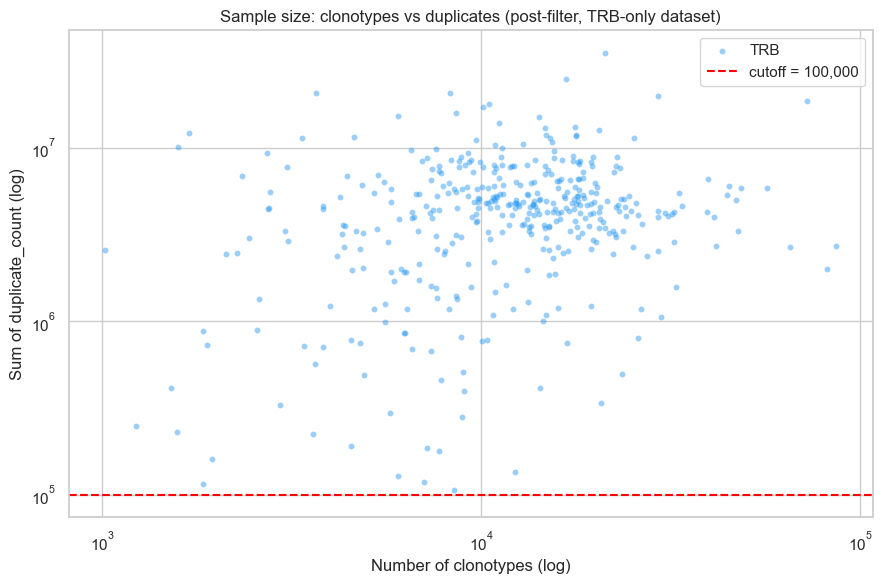

Samples shown: 401, loci: ['TRB']
Median n_clonotypes (TRB): 12258
Median total_duplicates (TRB): 4461298


In [5]:
# Log-log scatter: sum(duplicate_count) vs number of clonotypes per sample.
# Approx runtime: <10s once dataset is loaded in memory.

scatter_rows = []
for sid, srep in dataset.samples.items():
    for loc, lr in srep.loci.items():
        n_clones = lr.clonotype_count
        n_dups = lr.duplicate_count
        scatter_rows.append({'sample_id': sid, 'locus': loc, 'n_clonotypes': n_clones, 'total_duplicates': n_dups})

scatter_df = pd.DataFrame(scatter_rows)

fig, ax = plt.subplots(figsize=(9, 6))
palette = {'TRB': '#2196F3', 'TRA': '#FF5722'}
for loc, grp in scatter_df.groupby('locus'):
    ax.scatter(grp['n_clonotypes'], grp['total_duplicates'],
               label=loc, color=palette.get(loc, 'grey'), alpha=0.45, s=18, linewidths=0)

ax.axhline(MIN_DUPLICATE_COUNT, color='red', linestyle='--', linewidth=1.5,
           label=f'cutoff = {MIN_DUPLICATE_COUNT:,}')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Number of clonotypes (log)')
ax.set_ylabel('Sum of duplicate_count (log)')
ax.set_title('Sample size: clonotypes vs duplicates (post-filter, TRB-only dataset)')
ax.legend(framealpha=0.8)
plt.tight_layout()
plt.show()

print(f'Samples shown: {scatter_df["sample_id"].nunique()}, loci: {sorted(scatter_df["locus"].unique())}')
print(f'Median n_clonotypes (TRB): {scatter_df[scatter_df["locus"]=="TRB"]["n_clonotypes"].median():.0f}')
print(f'Median total_duplicates (TRB): {scatter_df[scatter_df["locus"]=="TRB"]["total_duplicates"].median():.0f}')

In [ ]:
def _gene_to_str(g):
    if isinstance(g, tuple):
        return '|'.join(map(str, g))
    return str(g)


HIST_BIN_WIDTH = 0.005
HEATMAP_CMAP = 'RdBu_r'
HEATMAP_STANDARD_SCALE = 1


def _uniform_bins(values: list[pd.Series], width: float = HIST_BIN_WIDTH, min_bins: int = 20):
    arr = pd.concat(values, ignore_index=True) if values else pd.Series(dtype=float)
    arr = pd.to_numeric(arr, errors='coerce').replace([np.inf, -np.inf], np.nan).dropna()
    if arr.empty:
        return np.linspace(0.0, 1.0, min_bins + 1)
    lo = float(arr.min())
    hi = float(arr.max())
    if hi <= lo:
        lo -= width
        hi += width
    start = np.floor(lo / width) * width
    stop = np.ceil(hi / width) * width
    n = max(min_bins, int(np.ceil((stop - start) / width)))
    return np.linspace(start, stop, n + 1)


def _build_sample_matrix(df: pd.DataFrame, value_col: str, locus: str = 'TRB') -> pd.DataFrame:
    d = df[df['locus'] == locus].copy()
    d['gene_str'] = d['gene'].map(_gene_to_str)
    mat = d.pivot_table(index='sample_id', columns='gene_str', values=value_col, aggfunc='mean', fill_value=0.0)
    row_sum = mat.sum(axis=1).replace(0, np.nan)
    mat = mat.div(row_sum, axis=0).fillna(0.0)
    return mat


def _scaled(mat: pd.DataFrame) -> np.ndarray:
    return StandardScaler(with_mean=True, with_std=True).fit_transform(mat.values)


def _pca_df(mat: pd.DataFrame, metadata_df: pd.DataFrame, n_components: int = 2):
    Xs = _scaled(mat)
    pca = PCA(n_components=n_components, random_state=42)
    Z = pca.fit_transform(Xs)
    out = pd.DataFrame(Z, index=mat.index, columns=[f'PC{i+1}' for i in range(n_components)])
    out = out.merge(metadata_df[['sample_id', 'batch_id']], left_index=True, right_on='sample_id', how='left')
    out['explained_var_pc1'] = pca.explained_variance_ratio_[0]
    out['explained_var_pc2'] = pca.explained_variance_ratio_[1] if n_components > 1 else np.nan
    return out, pca


def _umap_df(mat: pd.DataFrame, metadata_df: pd.DataFrame, **umap_kw):
    if not HAS_UMAP:
        return None
    Xs = _scaled(mat)
    kw = dict(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
    kw.update(umap_kw)
    Z = UMAPReducer(**kw).fit_transform(Xs)
    out = pd.DataFrame(Z, index=mat.index, columns=['UMAP1', 'UMAP2'])
    out = out.merge(metadata_df[['sample_id', 'batch_id']], left_index=True, right_on='sample_id', how='left')
    return out


def _batch_separability_metrics(embedding_df: pd.DataFrame, xy_cols=('PC1', 'PC2')) -> dict:
    lab = embedding_df['batch_id'].astype(str).values
    pts = embedding_df[list(xy_cols)].values
    uniq = pd.unique(lab)
    if len(uniq) < 2:
        return {'silhouette_batch': np.nan, 'kmeans_ari': np.nan, 'kmeans_nmi': np.nan}
    sil = silhouette_score(pts, lab)
    km = KMeans(n_clusters=len(uniq), random_state=42, n_init='auto').fit(pts)
    ari = adjusted_rand_score(lab, km.labels_)
    nmi = normalized_mutual_info_score(lab, km.labels_)
    return {'silhouette_batch': sil, 'kmeans_ari': ari, 'kmeans_nmi': nmi}


# Canonical label normalization for V gene names used across all cells.
HIGHLIGHT_GENES = ['TRBV6-2/TRBV6-3', 'TRBV28', 'TRBV4-3', 'TRBV3-2']
_MERGE_GENES = {'TRBV6-2', 'TRBV6-3'}

def _norm_v_label(gene_str: str) -> str:
    base = str(gene_str).upper().split('*')[0]
    return 'TRBV6-2/TRBV6-3' if base in _MERGE_GENES else base

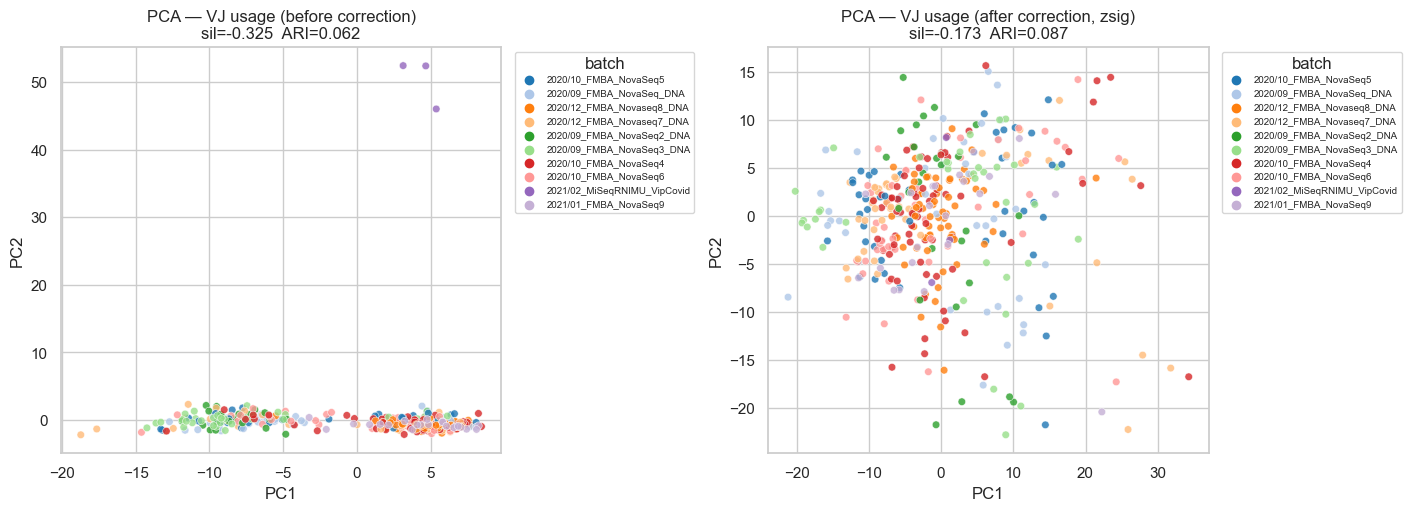

Batch separability — before: {'silhouette_batch': -0.3253654422128681, 'kmeans_ari': 0.061817779616530726, 'kmeans_nmi': 0.17566823213105742}
Batch separability — after : {'silhouette_batch': -0.1728027847776424, 'kmeans_ari': 0.08717949542448737, 'kmeans_nmi': 0.18090901128916492}


/Users/mikesh/vcs/mirpy/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
/Users/mikesh/vcs/mirpy/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


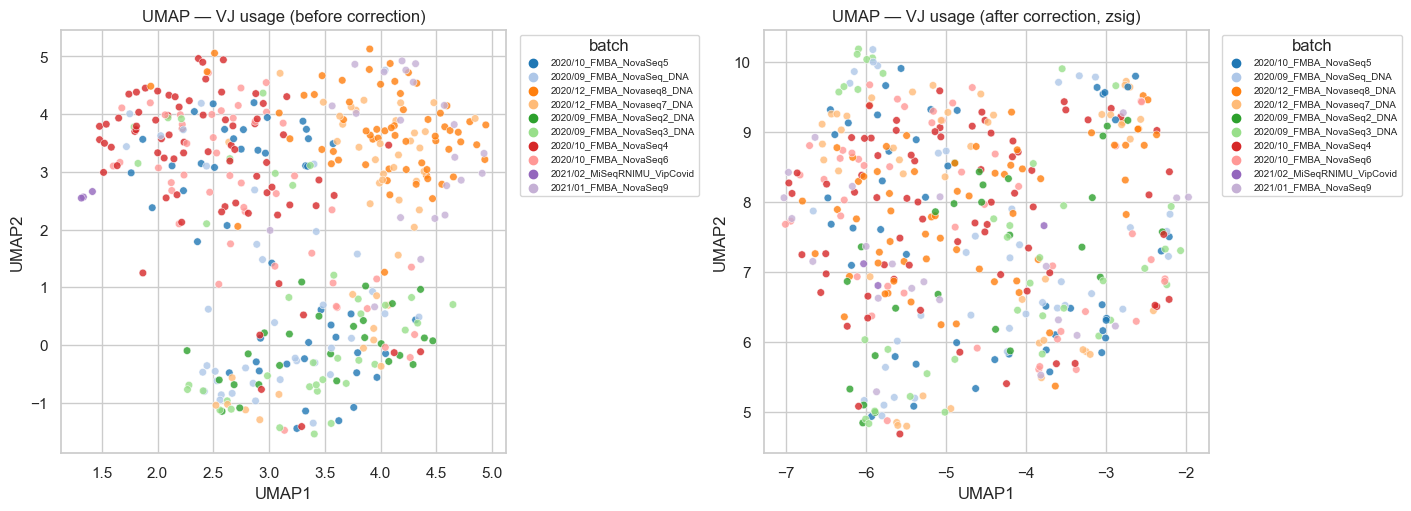

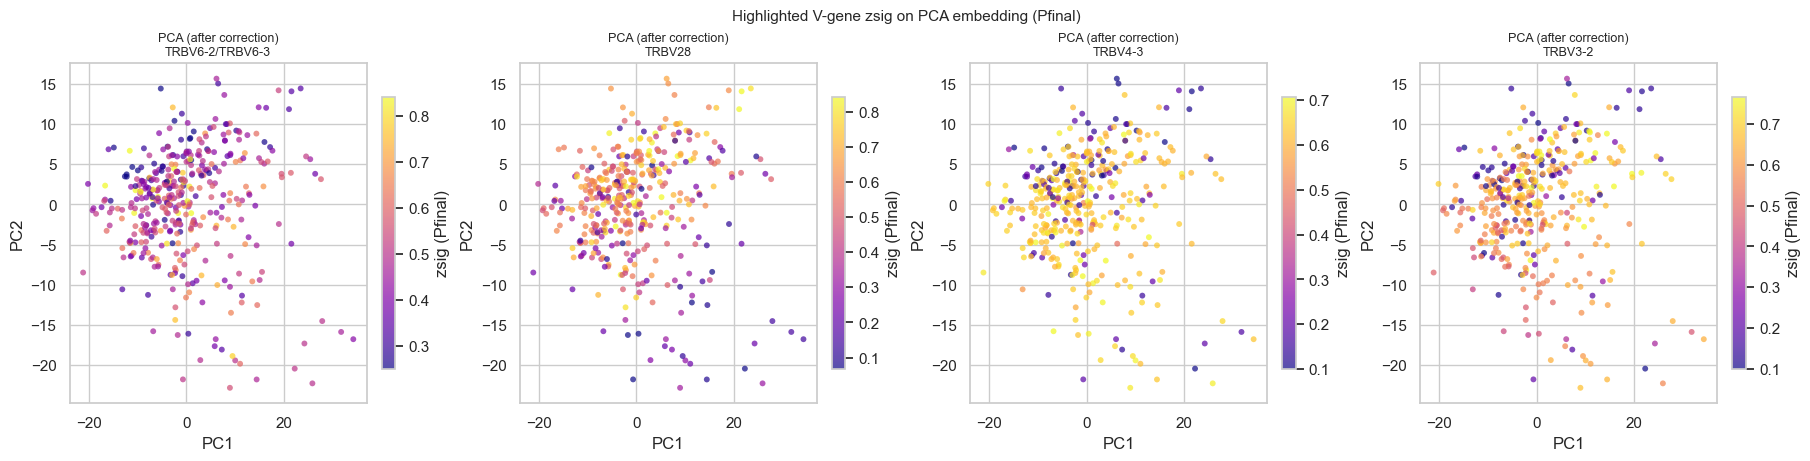

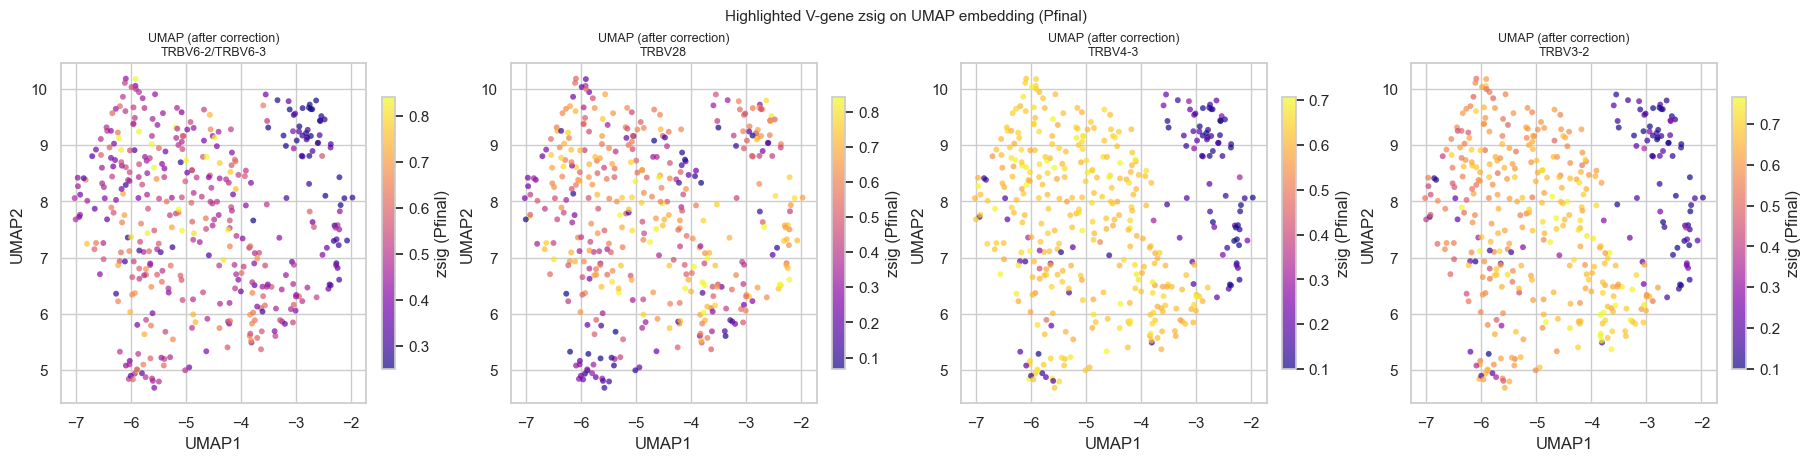

In [ ]:
# --- Batch-corrected VJ usage for TRB ---
corr_vj = compute_batch_corrected_gene_usage(
    dataset, batch_field='batch_id', scope='vj', weighted=True, pseudocount=1.0, z_cap=6.0
)

meta_df = dataset.metadata_df.reset_index(drop=True)

mat_before_vj = _build_sample_matrix(corr_vj, value_col='p', locus='TRB')
mat_after_vj   = _build_sample_matrix(corr_vj, value_col='pfinal', locus='TRB')

pca_before, _ = _pca_df(mat_before_vj, meta_df)
pca_after,  _ = _pca_df(mat_after_vj,  meta_df)

met_before = _batch_separability_metrics(pca_before)
met_after  = _batch_separability_metrics(pca_after)

# --- PCA scatter: batch coloring ---
n_batches = max(2, pca_before['batch_id'].nunique())
batch_palette = sns.color_palette('tab20', n_colors=n_batches)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
sns.scatterplot(data=pca_before, x='PC1', y='PC2', hue='batch_id', ax=axes[0],
                palette=batch_palette, s=30, alpha=0.8)
axes[0].set_title(
    f'PCA — VJ usage (before correction)\n'
    f'sil={met_before["silhouette_batch"]:.3f}  ARI={met_before["kmeans_ari"]:.3f}'
)
axes[0].legend(title='batch', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7)

sns.scatterplot(data=pca_after, x='PC1', y='PC2', hue='batch_id', ax=axes[1],
                palette=batch_palette, s=30, alpha=0.8)
axes[1].set_title(
    f'PCA — VJ usage (after correction, pfinal)\n'
    f'sil={met_after["silhouette_batch"]:.3f}  ARI={met_after["kmeans_ari"]:.3f}'
)
axes[1].legend(title='batch', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7)
plt.show()

print('Batch separability — before:', met_before)
print('Batch separability — after :', met_after)

# --- UMAP: batch coloring ---
umap_before = _umap_df(mat_before_vj, meta_df)
umap_after  = _umap_df(mat_after_vj,  meta_df)

if umap_before is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
    sns.scatterplot(data=umap_before, x='UMAP1', y='UMAP2', hue='batch_id', ax=axes[0],
                    palette=batch_palette, s=30, alpha=0.8)
    axes[0].set_title('UMAP — VJ usage (before correction)')
    axes[0].legend(title='batch', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7)

    sns.scatterplot(data=umap_after, x='UMAP1', y='UMAP2', hue='batch_id', ax=axes[1],
                    palette=batch_palette, s=30, alpha=0.8)
    axes[1].set_title('UMAP — VJ usage (after correction, pfinal)')
    axes[1].legend(title='batch', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7)
    plt.show()

# --- Highlighted V-gene usage on SHARED PCA/UMAP layout ---
corr_v = compute_batch_corrected_gene_usage(
    dataset, batch_field='batch_id', scope='v', weighted=True, pseudocount=1.0, z_cap=6.0
)
corr_v['gene_plot'] = corr_v['gene'].map(_norm_v_label)

# Wide table: sample_id -> gene_plot -> mean corrected probability (pfinal).
gene_wide = (
    corr_v[corr_v['locus'] == 'TRB']
    .groupby(['sample_id', 'gene_plot'])['pfinal']
    .mean()
    .unstack(fill_value=0.0)
)

available_highlights = [g for g in HIGHLIGHT_GENES if g in gene_wide.columns]

def _highlighted_scatter(embed_df, xy_cols, axes_row, title_prefix, cmap='viridis'):
    for ax, gene in zip(axes_row, available_highlights):
        vals = gene_wide.loc[embed_df['sample_id'].values, gene].values if gene in gene_wide.columns else np.zeros(len(embed_df))
        vmin = np.percentile(vals, 2)
        vmax = np.percentile(vals, 98)
        if vmax <= vmin:
            vmax = vmin + 1e-9
        sc = ax.scatter(embed_df[xy_cols[0]], embed_df[xy_cols[1]],
                        c=vals, cmap=cmap, alpha=0.7, s=18, linewidths=0,
                        vmin=vmin, vmax=vmax)
        plt.colorbar(sc, ax=ax, shrink=0.8, label='pfinal')
        ax.set_title(f'{title_prefix}\n{gene}', fontsize=9)
        ax.set_xlabel(xy_cols[0])
        ax.set_ylabel(xy_cols[1])

n_h = len(available_highlights)
if n_h > 0:
    # PCA highlighted panels
    pca_after_aligned = pca_after[pca_after['sample_id'].isin(gene_wide.index)].reset_index(drop=True)

    fig, axes = plt.subplots(1, n_h, figsize=(4.5 * n_h, 4.5), constrained_layout=True)
    if n_h == 1:
        axes = [axes]
    _highlighted_scatter(pca_after_aligned, ('PC1', 'PC2'), axes, 'PCA (after correction)', cmap='plasma')
    fig.suptitle('Highlighted V-gene pfinal on PCA embedding', fontsize=11)
    plt.show()

    # UMAP highlighted panels (if available)
    if umap_after is not None:
        umap_aligned = umap_after[umap_after['sample_id'].isin(gene_wide.index)].reset_index(drop=True)
        fig, axes = plt.subplots(1, n_h, figsize=(4.5 * n_h, 4.5), constrained_layout=True)
        if n_h == 1:
            axes = [axes]
        _highlighted_scatter(umap_aligned, ('UMAP1', 'UMAP2'), axes, 'UMAP (after correction)', cmap='plasma')
        fig.suptitle('Highlighted V-gene pfinal on UMAP embedding', fontsize=11)
        plt.show()

### Runtime note

The remaining embedding/correlation summary section is usually **1-3 minutes** on 401 TRB samples.

If rerunning repeatedly, keep earlier data-loading cells executed to avoid re-parse overhead.

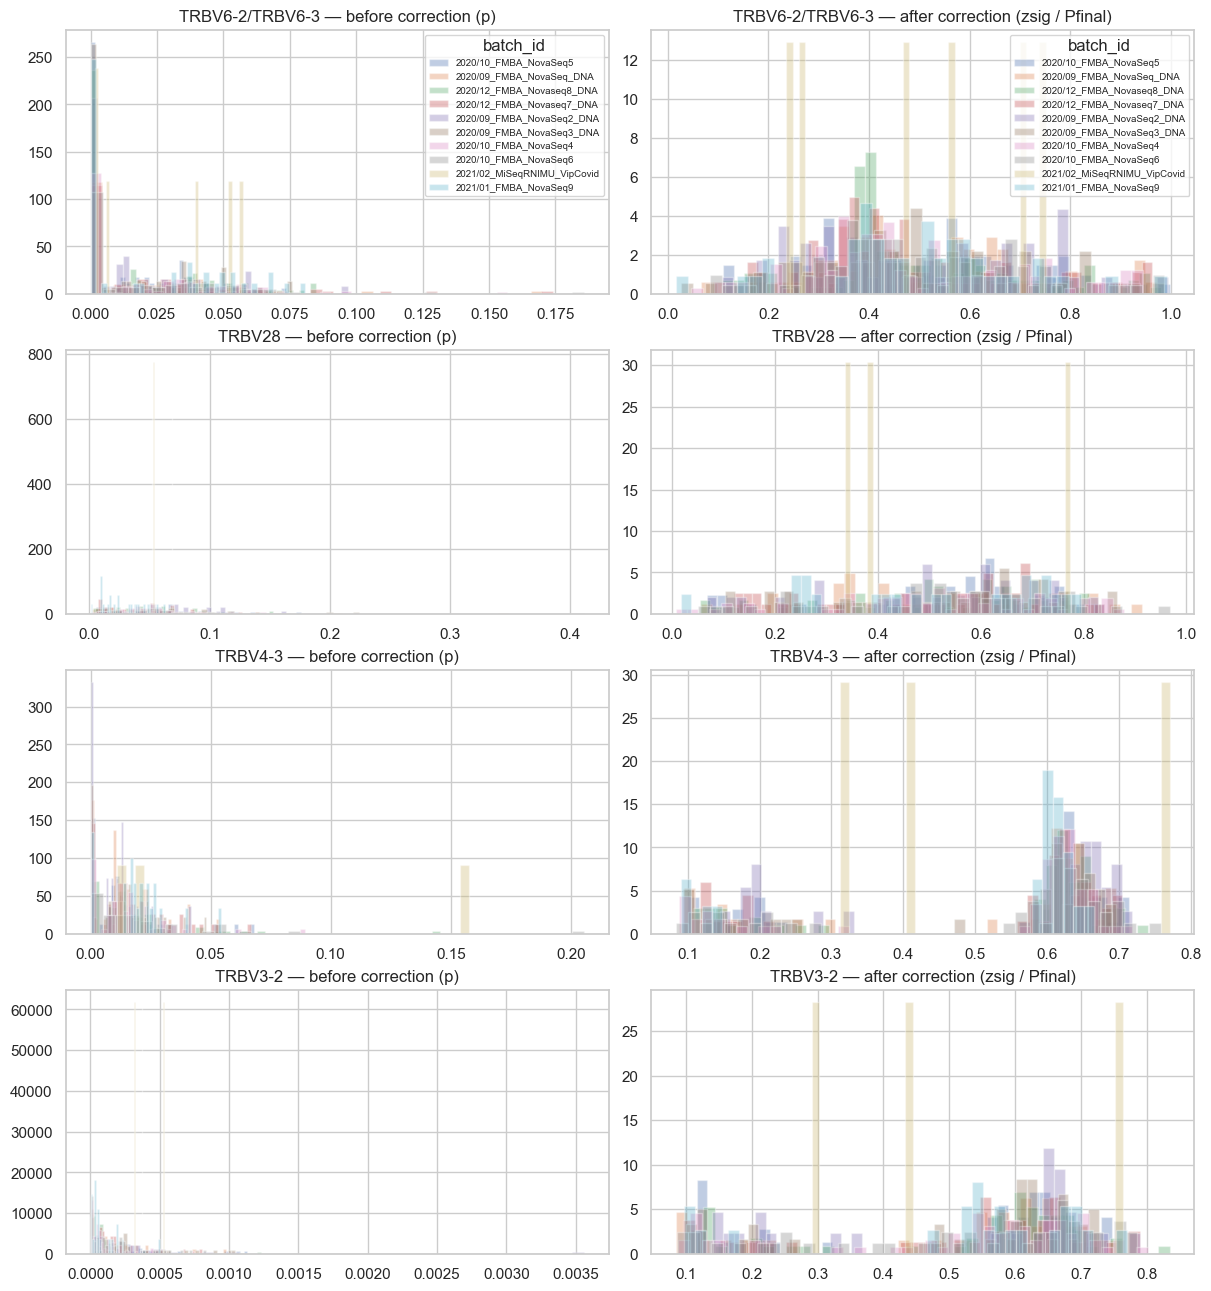

In [ ]:
# Distribution histograms for highlighted TRB V-genes: before vs after correction.
# corr_v is already computed in the previous cell.

corr_v_plot = corr_v.copy()
corr_v_plot['gene_plot'] = corr_v_plot['gene'].map(_norm_v_label)

if 'batch_id' not in corr_v_plot.columns:
    corr_v_plot = corr_v_plot.merge(meta_df[['sample_id', 'batch_id']], on='sample_id', how='left')

plot_genes = [g for g in HIGHLIGHT_GENES if g in corr_v_plot['gene_plot'].unique()]
if not plot_genes:
    top_var = corr_v_plot.groupby('gene_plot')['p'].var().sort_values(ascending=False)
    plot_genes = list(top_var.head(4).index)

n_g = len(plot_genes)
fig, axes = plt.subplots(n_g, 2, figsize=(12, 3.2 * n_g), constrained_layout=True)
if n_g == 1:
    axes = np.array([axes])

for i, g in enumerate(plot_genes):
    d = corr_v_plot[corr_v_plot['gene_plot'] == g].copy()
    bins = _uniform_bins([d['p'], d['pfinal']], width=HIST_BIN_WIDTH)

    for batch_id, grp in d.groupby('batch_id', sort=False):
        vals = pd.to_numeric(grp['p'], errors='coerce').replace([np.inf, -np.inf], np.nan).dropna()
        if len(vals) > 0:
            axes[i, 0].hist(vals, bins=bins, density=True, alpha=0.35, label=str(batch_id))
    axes[i, 0].set_title(f'{g} — before correction (p)')
    if i == 0:
        axes[i, 0].legend(title='batch_id', fontsize=7)

    for batch_id, grp in d.groupby('batch_id', sort=False):
        vals = pd.to_numeric(grp['pfinal'], errors='coerce').replace([np.inf, -np.inf], np.nan).dropna()
        if len(vals) > 0:
            axes[i, 1].hist(vals, bins=bins, density=True, alpha=0.35, label=str(batch_id))
    axes[i, 1].set_title(f'{g} — after correction (pfinal)')
    if i == 0:
        axes[i, 1].legend(title='batch_id', fontsize=7)

plt.show()

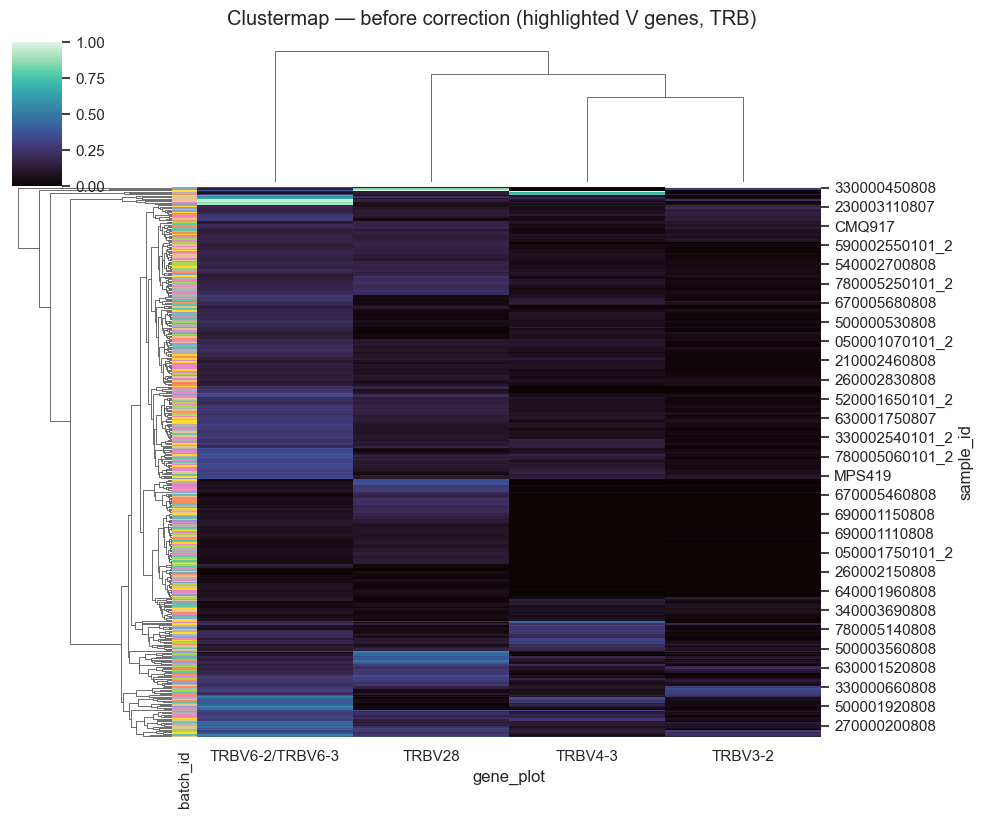

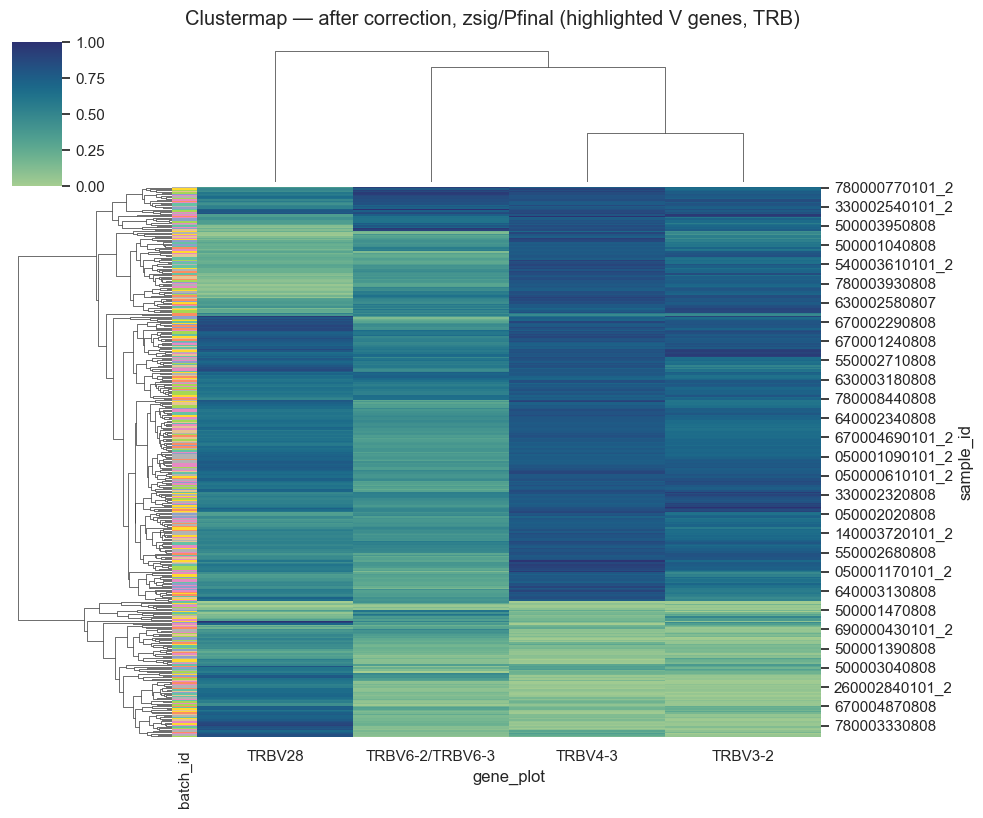

In [ ]:
# Clustermap: highlighted V-gene usage before and after correction (TRB only).
before_v = corr_v_plot.pivot_table(index='sample_id', columns='gene_plot', values='p', aggfunc='mean', fill_value=0.0)
after_v  = corr_v_plot.pivot_table(index='sample_id', columns='gene_plot', values='pfinal', aggfunc='mean', fill_value=0.0)

available_h = [g for g in HIGHLIGHT_GENES if g in before_v.columns]
if not available_h:
    available_h = list(before_v.var(axis=0).sort_values(ascending=False).head(20).index)

before_h = before_v[available_h]
after_h  = after_v[available_h]

batch_series = meta_df.set_index('sample_id').loc[before_h.index, 'batch_id'].astype(str)
batch_palette = dict(zip(sorted(batch_series.unique()), sns.color_palette('Set2', n_colors=batch_series.nunique())))
row_colors = batch_series.map(batch_palette)

sns.clustermap(
    before_h,
    cmap=HEATMAP_CMAP,
    row_colors=row_colors,
    figsize=(10, 8),
    standard_scale=HEATMAP_STANDARD_SCALE,
    linewidths=0.2,
    linecolor='white',
)
plt.suptitle('Clustermap — before correction (highlighted V genes, TRB)', y=1.02)
plt.show()

sns.clustermap(
    after_h,
    cmap=HEATMAP_CMAP,
    row_colors=row_colors,
    figsize=(10, 8),
    standard_scale=HEATMAP_STANDARD_SCALE,
    linewidths=0.2,
    linecolor='white',
)
plt.suptitle('Clustermap — after correction (pfinal, highlighted V genes, TRB)', y=1.02)
plt.show()

Resampled:           401 samples
Resampled+filtered:  401 samples


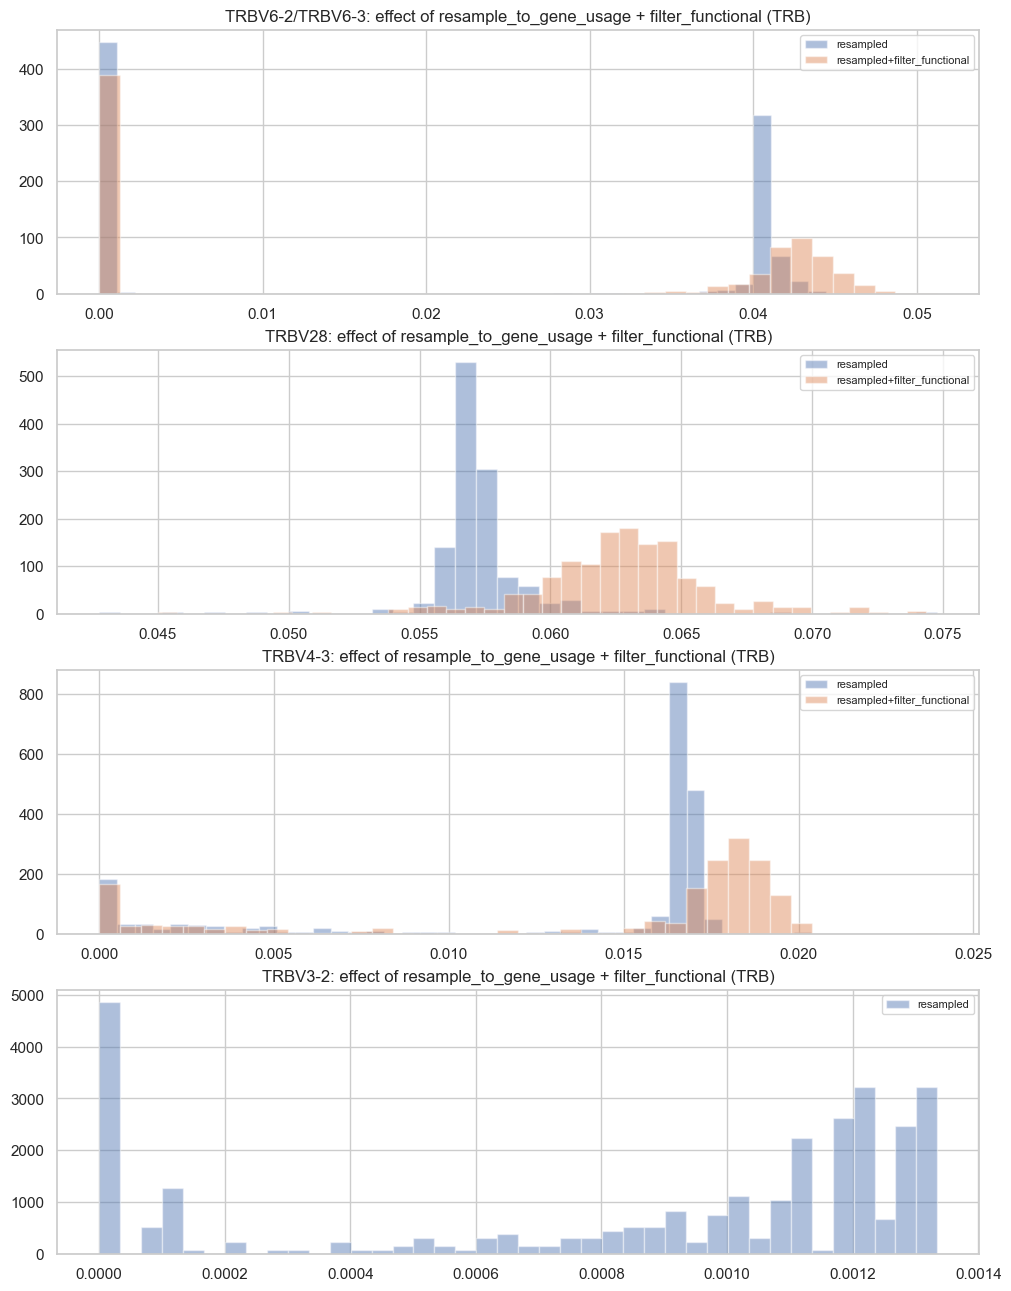


=== Final TRB cohort statistics ===
Samples: 401
Batches: 10
Total clonotypes: 5,696,275
Total duplicates: 1,992,667,702


(        sample_id                   batch_id  n_loci  n_clonotypes  \
 0    020000280808      2020/10_FMBA_NovaSeq5       1          6144   
 1    020000340808      2020/10_FMBA_NovaSeq5       1          7386   
 2    020000640808      2020/10_FMBA_NovaSeq5       1          1230   
 3    020000710808   2020/09_FMBA_NovaSeq_DNA       1          8579   
 4  020003830101_2  2020/12_FMBA_Novaseq8_DNA       1         14561   
 
    n_duplicates  
 0       2005779  
 1       6526027  
 2        249110  
 3      15734325  
 4       2622740  ,
                              n_samples  n_clonotypes  n_duplicates
 batch_id                                                          
 2020/10_FMBA_NovaSeq4               73       1113585     326068354
 2020/12_FMBA_Novaseq8_DNA           63       1024521     270622299
 2020/10_FMBA_NovaSeq6               47        631002     279287251
 2020/10_FMBA_NovaSeq5               46        455456     225514482
 2020/12_FMBA_Novaseq7_DNA           45        71

In [ ]:
# --- Resampling to pooled VJ target + functional filtering ---
# Approx runtime: 20-60s for ~400 TRB samples depending on clone counts.
target_scale = 10_000
target_vj_usage = {
    row['gene']: max(1, int(round(float(row['pavg']) * target_scale)))
    for _, row in (
        corr_vj[corr_vj['locus'] == 'TRB']
        .drop_duplicates('gene')[['gene', 'pavg']]
        .iterrows()
    )
}

resampled_samples = {}
resampled_filtered_samples = {}

for sid, srep in dataset.samples.items():
    if 'TRB' not in srep.loci:
        continue
    trb_resampled = resample_to_gene_usage(
        srep.loci['TRB'], target_vj_usage, scope='vj', weighted=True, random_seed=42,
    )
    s_res = type(srep)(loci={'TRB': trb_resampled}, sample_id=sid, sample_metadata=dict(srep.sample_metadata))
    resampled_samples[sid] = s_res
    resampled_filtered_samples[sid] = filter_functional(s_res)

dataset_resampled = RepertoireDataset(samples=resampled_samples)
dataset_resampled_filtered = RepertoireDataset(samples=resampled_filtered_samples)

print(f'Resampled:           {len(dataset_resampled.samples)} samples')
print(f'Resampled+filtered:  {len(dataset_resampled_filtered.samples)} samples')

# V-gene distributions after resampling and functional filtering.
corr_res_v = compute_batch_corrected_gene_usage(
    dataset_resampled, batch_field='batch_id', scope='v', weighted=True
)
corr_res_v['gene_plot'] = corr_res_v['gene'].map(_norm_v_label)

corr_resf_v = compute_batch_corrected_gene_usage(
    dataset_resampled_filtered, batch_field='batch_id', scope='v', weighted=True
)
corr_resf_v['gene_plot'] = corr_resf_v['gene'].map(_norm_v_label)

dist_comp = pd.concat([
    corr_res_v.assign(dataset='resampled'),
    corr_resf_v.assign(dataset='resampled+filter_functional'),
], ignore_index=True)

genes_to_show = [g for g in HIGHLIGHT_GENES if g in set(dist_comp['gene_plot'])]
if not genes_to_show:
    genes_to_show = sorted(dist_comp['gene_plot'].unique())[:4]

n_g = len(genes_to_show)
fig, axes = plt.subplots(n_g, 1, figsize=(10, 3.2 * n_g), constrained_layout=True)
if n_g == 1:
    axes = [axes]

for ax, g in zip(axes, genes_to_show):
    d = dist_comp[dist_comp['gene_plot'] == g].copy()
    bins = _uniform_bins([d['p']], width=HIST_BIN_WIDTH)
    for ds_name, grp in d.groupby('dataset', sort=False):
        vals = pd.to_numeric(grp['p'], errors='coerce').replace([np.inf, -np.inf], np.nan).dropna()
        if len(vals) > 0:
            ax.hist(vals, bins=bins, density=True, alpha=0.45, label=str(ds_name))
    ax.set_title(f'{g}: effect of resample_to_gene_usage + filter_functional (TRB)')
    ax.legend(fontsize=8)

plt.show()

# --- Final cohort statistics ---
sample_rows = []
for sid, srep in dataset.samples.items():
    n_clones = srep.clonotype_count
    n_dups = srep.duplicate_count
    sample_rows.append({
        'sample_id': sid,
        'batch_id':  str(dataset.metadata[sid].get('batch_id', 'NA')),
        'n_loci':    len(srep.loci),
        'n_clonotypes': n_clones,
        'n_duplicates': n_dups,
    })

stats_df = pd.DataFrame(sample_rows)
batch_stats = stats_df.groupby('batch_id').agg(
    n_samples=('sample_id', 'nunique'),
    n_clonotypes=('n_clonotypes', 'sum'),
    n_duplicates=('n_duplicates', 'sum'),
).sort_values('n_samples', ascending=False)

print('\n=== Final TRB cohort statistics ===')
print(f'Samples: {stats_df["sample_id"].nunique()}')
print(f'Batches: {stats_df["batch_id"].nunique()}')
print(f'Total clonotypes: {stats_df["n_clonotypes"].sum():,}')
print(f'Total duplicates: {stats_df["n_duplicates"].sum():,}')
stats_df.head(), batch_stats